In [1]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from multiprocess import Pool
from had_model import HAD_model
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Temporal evolution of hyperedges

Here we study the temporal evolution of:
- relative number of hyperedges (w.r.t. the initial number)
- average hyperedge size (± standard deviation)
- maximum hyperedge size

We fix some parameters of the starting structure: ER hypergraph, $M=4,\ \langle k \rangle = 10$, condition for agreement = max-min.

In [4]:
eps = 0.4
cond = 'max_min'   # condition for agreement
k_avg = 10
M = 4
n_runs = 50    # number of n_runs

# auxiliary functions to parallelize computations
def get_temporal_results(N):
        
    # All below quantities are computed along time, then averaged over 'n_runs'
    nhe = []      # relative number of hyperedges
    s_avg = []    # average hyperedge size
    s_max = []    # max hyperedge size
    s_std = []    # std of hyperedge sizes
    n_agree = []
    n_merge = []
    n_split = []
    
    for it in tqdm(range(n_runs)):

        nhe_it, s_avg_it = [], []   
        s_max_it, s_std_it = [], []
        
        H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
        H.cleanup()
        groups_0 = H.edges.members()
        
        Model = HAD_model(eps, groups_0)
        results = Model.simulate(condition=cond, sgbr=False)
        opinions = results['opinions']
        groups = results['groups']
        n_events = results['n_events']
        T = len(groups)
        
        # get results over time t
        for t in range(T):
            sizes_t = [len(he) for he in groups[t]]
            s_avg_it.append( np.average(sizes_t) )
            s_max_it.append( max(sizes_t) )
            s_std_it.append( np.std(sizes_t) )
            nhe_it.append( len(groups[t]) / len(groups_0) )
        
        nhe.append(nhe_it)
        s_avg.append(s_avg_it)
        s_max.append(s_max_it)
        s_std.append(s_std_it)
        n_agree.append(n_events['agree'])
        n_split.append(n_events['split'])
        n_merge.append(n_events['merge'])

    # maximum simulation time among all the runs
    T_max = max([len(x) for x in nhe])
    res = []
    for measure in [nhe, s_avg, s_max, s_std, n_agree, n_split, n_merge]:
        # pad list of lists with last values at steady state, 
        # to obtain a rectangular matrix of shape (n_runs, T_max)
        measure = [x + [x[-1]] * (T_max-len(x)) for x in measure]
        # take the column-wise average over all the n_runs
        res.append( np.average(measure, axis=0) )
    
    results = {
        'nhe': res[0],
        's_avg': res[1],
        's_max': res[2],
        's_std': res[3],
        'n_agree': res[4],
        'n_split': res[5],
        'n_merge': res[6],
        'n_runs': n_runs,
        'k_avg': k_avg
        }
    
    return results

In [8]:
Ns = [500, 1000, 2000, 5000]

p = Pool(processes=4)
results_ = p.map(get_temporal_results, Ns)

# save results
results = {Ns[i]: results_[i] for i in range(len(Ns))}

with open(f'../results/ER_M{M}_{cond}_epsilon_{eps}_temporal.pkl', 'wb') as fp:
        pickle.dump(results, fp)

100%|████████████████████████████████████████| 50/50 [1:43:26<00:00, 124.14s/it]


/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1341/27560817.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend


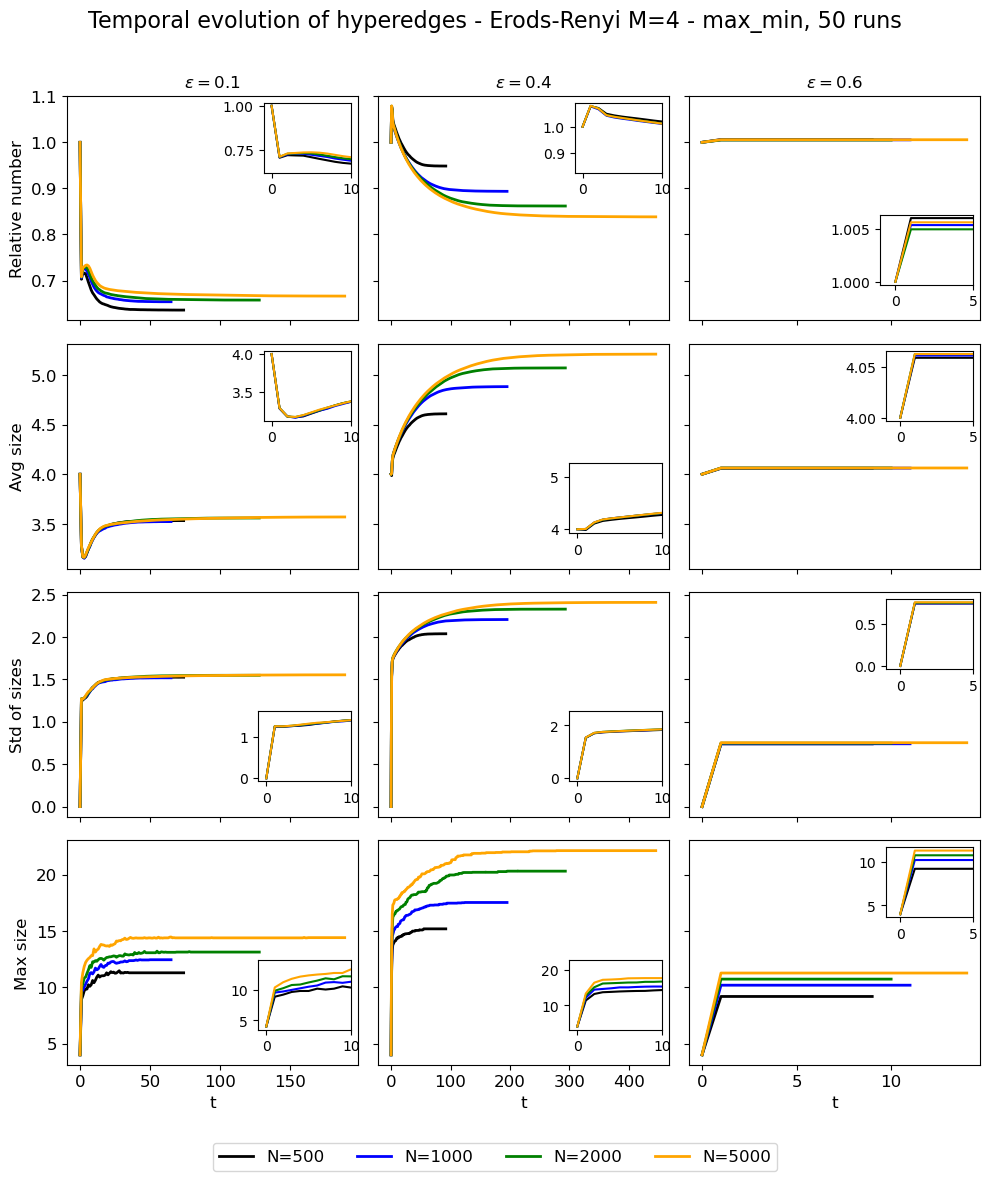

In [10]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4, 0.6]

fig, axs = plt.subplots(4, len(epsilons), sharex='col', sharey='row', figsize=(10,12))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Relative number', 'Avg size', 'Std of sizes', 'Max size']

# We'll collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_M{M}_{cond}_epsilon_{eps}_temporal.pkl', 'rb') as f:
        results = pickle.load(f)

    xlim = 10
    if j==2:
        xlim=5
    inset_ax = []
    cr = [(0,2),(1,1),(2,0),(2,1),(3,0),(3,1)]
    for i in range(4):
        if (i,j) in cr:
            inset_ax.append( inset_axes(axs[i, j], width="40%", height=0.7, bbox_to_anchor=(.2, .3, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )
        else:
            inset_ax.append( inset_axes(axs[i, j], width="30%", height=0.7, loc=1) )

    for N, clr in zip(Ns, colors):
        nhe = results[N]['nhe']
        s_avg = results[N]['s_avg']
        s_max = results[N]['s_max']
        s_std = results[N]['s_std']
        n_runs = results[N]['n_runs']
        k_avg = results[N]['k_avg']

        line1, = axs[0, j].plot(nhe, color=clr, lw=2, label=f'N={N}')
        inset_ax[0].set_xlim(-1, xlim)
        inset_ax[0].plot(nhe, color=clr)

        axs[1, j].plot(s_avg, color=clr, lw=2)
        inset_ax[1].set_xlim(-1, xlim)
        inset_ax[1].plot(s_avg, color=clr)

        axs[2, j].plot(s_std, color=clr, lw=2)
        inset_ax[2].set_xlim(-1, xlim)
        inset_ax[2].plot(s_std, color=clr)

        axs[3, j].plot(s_max, color=clr, lw=2)
        axs[3, j].set_xlabel(r't', fontsize=lgd_size)
        inset_ax[3].set_xlim(-1, xlim)
        inset_ax[3].plot(s_max, color=clr)            

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=lgd_size)

    for i in range(4):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=lgd_size)
        axs[i, j].tick_params(labelsize=lgd_size)

# Super title
plt.suptitle(f'Temporal evolution of hyperedges - Erods-Renyi M={M} - {cond}, {n_runs} runs', fontsize=ttl_size)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.005),
           fontsize=lgd_size, ncol=len(Ns))

plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_hedges.jpg', bbox_inches='tight')
plt.show()

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2048/2395508870.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend


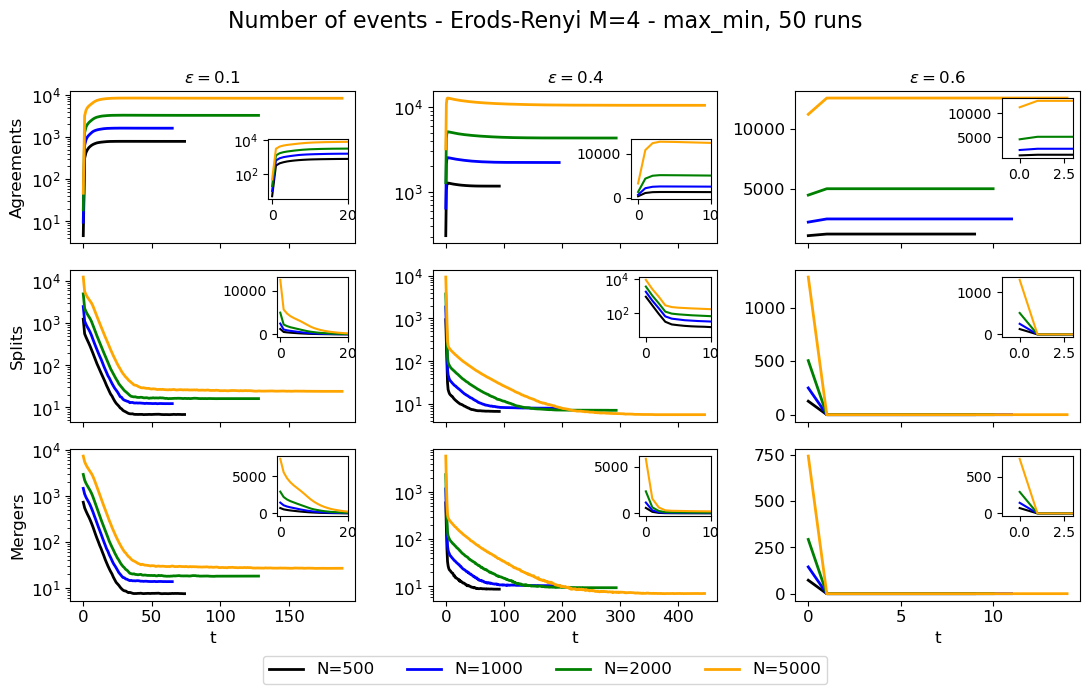

In [6]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.4, 0.6]

fig, axs = plt.subplots(3, len(epsilons), sharex='col', figsize=(11,7))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']
xlims = [20,10,3]   # for inset plots

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_M{M}_{cond}_epsilon_{eps}_temporal.pkl', 'rb') as f:
        results = pickle.load(f)

    inset_ax = []
    cr = [(0,0),(0,1)]
    for i in range(3):
        if (i,j) in cr:
            inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.6, bbox_to_anchor=(.2, .53, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )
        else:
            inset_ax.append( inset_axes(axs[i, j], width="25%", height=0.6, loc=1) )

    for N, clr in zip(Ns, colors):
        n_agree = results[N]['n_agree']
        n_split = results[N]['n_split']
        n_merge = results[N]['n_merge']
        n_runs = results[N]['n_runs']
        k_avg = results[N]['k_avg']

        line1, = axs[0, j].plot(n_agree, color=clr, lw=2, label=f'N={N}')
        inset_ax[0].set_xlim(-1, xlims[j])
        inset_ax[0].plot(n_agree, color=clr)

        axs[1, j].plot(n_split, color=clr, lw=2)
        inset_ax[1].set_xlim(-1, xlims[j])
        inset_ax[1].plot(n_split, color=clr)

        axs[2, j].plot(n_merge, color=clr, lw=2)
        axs[2, j].set_xlabel(r't', fontsize=lgd_size)
        inset_ax[2].set_xlim(-1, xlims[j])
        inset_ax[2].plot(n_merge, color=clr)       

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=lgd_size)

    for i in range(3):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=lgd_size)
        axs[i, j].tick_params(labelsize=lgd_size)
        if j<2:
            axs[i, j].set_yscale('log')
            inset_ax[j].set_yscale('log')


plt.suptitle(f'Number of events - Erods-Renyi M={M} - {cond}, {n_runs} runs', fontsize=ttl_size)

# Adjust layout to make space for legend
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # leave space at bottom for legend

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.5, 0.005),
           fontsize=lgd_size, ncol=len(Ns))

#plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_n_events.jpg', bbox_inches='tight')
plt.show()

# Checks on split-merge dynamics

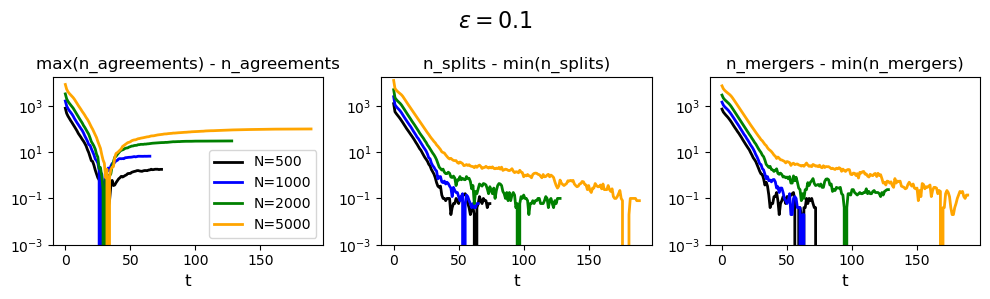

In [59]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_M4_max_min_epsilon_{epsilon}_temporal.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    n_runs = results[N]['n_runs']
    k_avg = results[N]['k_avg']
    
    n_ag = [max(n_agree) - i for i in n_agree]
    n_sp = [i - min(n_split) for i in n_split]
    n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_ag, color=clr, lw=2, label=f'N={N}')
    ax[1].plot(n_sp, color=clr, lw=2, label=f'N={N}')
    ax[2].plot(n_me, color=clr, lw=2, label=f'N={N}')
    ax[0].set_title('max(n_agreements) - n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits - min(n_splits)', fontsize=ttl_size)
    ax[2].set_title('n_mergers - min(n_mergers)', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.001, 17000)
        ax[i].set_yscale('log')

plt.suptitle(rf'$\epsilon =${epsilon}', fontsize=16)

plt.tight_layout()
plt.show()

# Single run to check what happens

In [15]:
eps = 0.1
cond = 'max_min'   # condition for agreement
k_avg = 10
M = 4

# auxiliary functions to parallelize computations
def get_temporal_results_one_run(N):
        
    # All below quantities are computed along time, then averaged over 'n_runs'
    nhe = []      # relative number of hyperedges
    s_avg = []    # average hyperedge size
    s_max = []    # max hyperedge size
    s_std = []    # std of hyperedge sizes
    n_agree = []
    n_merge = []
    n_split = []
    
    
    H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
    H.cleanup()
    groups_0 = H.edges.members()
    Model = HAD_model(eps, groups_0)
    results = Model.simulate(T=600, condition=cond, sgbr=False)
    opinions = results['opinions']
    groups = results['groups']
    n_events = results['n_events']
    T = len(groups)

    final_ops = [opinions[n][-1] for n in H.nodes]
    # get results over time t
    for t in range(T):
        sizes_t = [len(he) for he in groups[t]]
        s_avg.append( np.average(sizes_t) )
        s_max.append( max(sizes_t) )
        s_std.append( np.std(sizes_t) )
        nhe.append( len(groups[t]) / len(groups_0) )
        
    res = {
        'nhe': nhe,
        's_avg': s_avg,
        's_max': s_max,
        's_std': s_std,
        'n_agree': n_events['agree'],
        'n_split': n_events['split'],
        'n_merge': n_events['merge'],
        'final_opinions': final_ops,
        'k_avg': k_avg
        }
    
    return res

In [17]:
%%time

Ns = [500, 1000, 2000, 5000]

p = Pool(processes=4)
results_ = p.map(get_temporal_results_one_run, Ns)

# save results
results = {Ns[i]: results_[i] for i in range(len(Ns))}

with open(f'../results/ER_M{M}_{cond}_epsilon_{eps}_temporal_one_run.pkl', 'wb') as fp:
        pickle.dump(results, fp)

CPU times: user 21 ms, sys: 31.2 ms, total: 52.2 ms
Wall time: 3min 6s


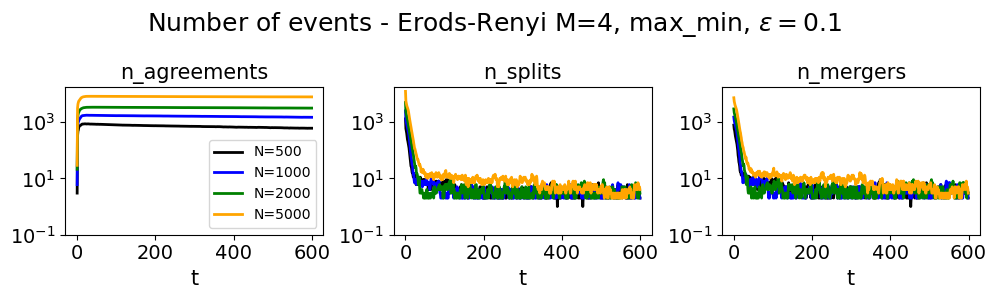

In [18]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N
lbl_list = ['Agreements', 'Splits', 'Mergers']

fig, ax = plt.subplots(1,3, figsize=(10,3))

for N,clr in zip(Ns,colors):
    n_agree = results[N]['n_agree']
    n_split = results[N]['n_split']
    n_merge = results[N]['n_merge']
    k_avg = results[N]['k_avg']
    
    #n_ag = [max(n_agree) - i for i in n_agree]
    #n_sp = [i - min(n_split) for i in n_split]
    #n_me = [i - min(n_merge) for i in n_merge]
    
    ax[0].plot(n_agree, color=clr, lw=2, label=f'N={N}')
    ax[1].plot(n_split, color=clr, lw=2, label=f'N={N}')
    ax[2].plot(n_merge, color=clr, lw=2, label=f'N={N}')
    ax[0].set_title('n_agreements', fontsize=ttl_size)
    ax[1].set_title('n_splits', fontsize=ttl_size)
    ax[2].set_title('n_mergers', fontsize=ttl_size)
    ax[0].legend()

    for i in range(3):
        ax[i].tick_params(labelsize=14)
        ax[i].set_yscale('log')
        ax[i].set_xlabel('t', fontsize=ttl_size)
        ax[i].set_ylim(0.1, 17000)
            
plt.suptitle(rf'Number of events - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=18)

plt.tight_layout()
plt.show()

N=500
Final number of different opinions:  7
Final clusters of opinions:  {0.6667: 141, 0.3771: 123, 0.9064: 102, 0.1495: 124, 0.275: 1, 0.8052: 1, 0.0288: 8} 

N=1000
Final number of different opinions:  7
Final clusters of opinions:  {0.6075: 341, 0.3064: 238, 0.1058: 180, 0.9989: 1, 0.8794: 237, 0.4545: 2, 0.9898: 1} 

N=2000
Final number of different opinions:  7
Final clusters of opinions:  {0.109: 375, 0.5131: 470, 0.9054: 376, 0.3027: 346, 0.7136: 431, 0.0048: 1, 0.0008: 1} 

N=5000
Final number of different opinions:  9
Final clusters of opinions:  {0.4993: 1243, 0.2905: 1047, 0.7114: 861, 0.0977: 855, 0.8917: 987, 0.9957: 3, 0.9988: 2, 0.9943: 1, 0.3917: 1} 



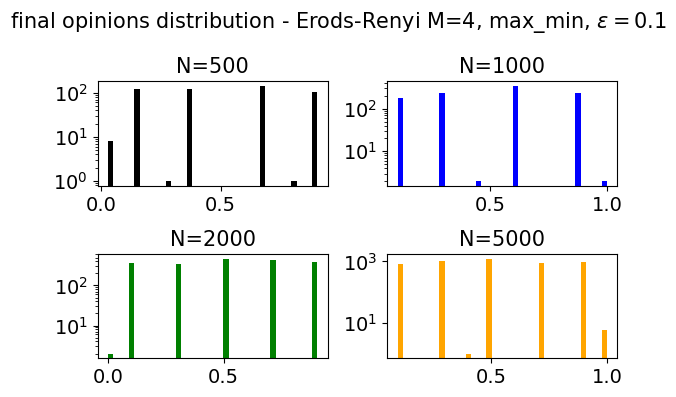

In [25]:
Ns = [500, 1000, 2000, 5000]
epsilon = 0.1

with open(f'../results/ER_M4_max_min_epsilon_{epsilon}_temporal_one_run.pkl', 'rb') as f:
    results = pickle.load(f)

ttl_size = 15
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

fig, ax = plt.subplots(2,2, figsize=(6,4))

for i in range(len(Ns)):
    N, clr = Ns[i], colors[i]
    ops_dist = results[N]['final_opinions']
    nhe = results[N]['nhe']
    k_avg = results[N]['k_avg']

    j, k = int(i/2), i%2
    ax[j,k].hist(ops_dist, bins=40, color=clr)
    ax[j,k].set_title(f'N={N}', fontsize=ttl_size)

    for i in range(4):
        ax[j,k].tick_params(labelsize=14)
        ax[j,k].set_yscale('log')

    ops_dist = [np.round(i,4) for i in ops_dist]
    unique_ops = list(set(ops_dist))
    clst_op = {i :ops_dist.count(i) for i in unique_ops}
    print(f'N={N}')
    print('Final number of different opinions: ', len(unique_ops) )
    print(f'Final clusters of opinions: ', clst_op, '\n' )

plt.suptitle(rf'final opinions distribution - Erods-Renyi M=4, {cond}, $\epsilon =${epsilon}', fontsize=ttl_size)

plt.tight_layout()
plt.show()